In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/new dataset/heart disease pred.csv')
print(df.head())

# Separate features and target
X = df.drop(['target', 'Name'], axis=1, errors='ignore')
y = df['target']

              Name  Age     Sex  Cholesterol Level  Blood Pressure  \
0     Daniel Perry   14  Female           9.341193      229.035586   
1      Lauren Luna   21  Female           9.149010      200.239637   
2     Andrew Lewis   31    Male           9.768630      267.343650   
3  Trevor Villegas   19    Male          11.915923      221.104453   
4       John Mills   30  Female           9.500291      230.140212   

   Heart Rate    Diabetes  Excersice Hour per Week        Diet  Triglycerides  \
0         NaN  144.987111                73.711588   72.047328       1.312437   
1   16.153480  104.192937                25.896181   67.512312       0.221304   
2   14.373756  153.177037                45.918204   76.687723       3.533976   
3    4.326112  159.542682                53.625145  103.375310       1.549835   
4   23.433224  124.989992                68.076335   82.279210       3.895870   

   ...  Stress Level  Physical Activity  Sedentary Hours Per Day  Obesity  \
0  ...    127.9

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print(f"Numerical columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

# Numeric imputation
num_imputer = SimpleImputer(strategy='mean')
X[num_cols] = num_imputer.fit_transform(X[num_cols])

if len(cat_cols) > 0:
    # Categorical imputation
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

    # Encoding categorical features
    for col in cat_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
else:
    print("No categorical columns found, skipping categorical imputation and encoding.")


Numerical columns: Index(['Age', 'Cholesterol Level', 'Blood Pressure', 'Heart Rate', 'Diabetes',
       'Excersice Hour per Week', 'Diet', 'Triglycerides', 'Sleep Hour',
       'Previous heart disease', 'Medication use', 'Stress Level',
       'Physical Activity', 'Sedentary Hours Per Day', 'Obesity',
       'Family History', 'Smoking', 'BMI'],
      dtype='object')
Categorical columns: Index(['Sex', 'Region'], dtype='object')


In [ ]:
rf_temp = RandomForestClassifier(random_state=42)
# No fitting or dropping here anymore

In [ ]:
# Split data AFTER imputation and encoding, but BEFORE scaling and feature selection
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Identify numeric and categorical columns *after* the split
num_cols_train = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols_train = X_train.select_dtypes(include=['object']).columns # Exclude boolean here

# Numeric imputation on train/test
num_imputer = SimpleImputer(strategy='mean')
X_train[num_cols_train] = num_imputer.fit_transform(X_train[num_cols_train])
X_test[num_cols_train] = num_imputer.transform(X_test[num_cols_train])

if len(cat_cols_train) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train[cat_cols_train] = cat_imputer.fit_transform(X_train[cat_cols_train])
    X_test[cat_cols_train] = cat_imputer.transform(X_test[cat_cols_train])

    # Encoding categorical features
    for col in cat_cols_train:
        le = LabelEncoder()
        # Use .astype(str) before fit_transform and transform to handle potential non-string types
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))
else:
    print("No categorical columns for train/test sets, skipping categorical imputation and encoding.")

# Convert boolean columns to integers after imputation and encoding
bool_cols_train = X_train.select_dtypes(include=['bool']).columns
for col in bool_cols_train:
    X_train[col] = X_train[col].astype(int)
    X_test[col] = X_test[col].astype(int)

# Now perform feature selection on the training data *after* splitting, imputation, and encoding
rf_temp = RandomForestClassifier(random_state=42)
rf_temp.fit(X_train, y_train)
importances = pd.Series(rf_temp.feature_importances_, index=X_train.columns)

# Drop the top TWO most important features from both train and test sets
top_features = importances.nlargest(2).index.tolist()
print(f"Dropping top 2 most important features from train and test: {top_features}")

X_train = X_train.drop(top_features, axis=1)
X_test = X_test.drop(top_features, axis=1)

# Save the list of features after dropping the top features
features_used = X_train.columns.tolist()


# Move scaling after subsetting X_train and X_test and ensuring consistency
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Debugging prints for confirmation
print("Training columns after dropping features:", X_train.columns.tolist())
print("Test columns after dropping features:", X_test.columns.tolist())

print(f"Shape of X_train after subsetting and scaling: {X_train_scaled.shape}")
print(f"Shape of X_test after subsetting and scaling: {X_test_scaled.shape}")

No categorical columns for train/test sets, skipping categorical imputation and encoding.
Dropping top 2 most important features from train and test: ['Diabetes', 'Physical Activity']
Training columns after dropping features: ['Sex', 'Cholesterol Level', 'Heart Rate', 'Excersice Hour per Week', 'Diet', 'Triglycerides', 'Sleep Hour', 'Previous heart disease', 'Medication use', 'Stress Level', 'Sedentary Hours Per Day', 'Obesity', 'Family History', 'Smoking', 'Region', 'Alcohol Use', 'BMI']
Test columns after dropping features: ['Sex', 'Cholesterol Level', 'Heart Rate', 'Excersice Hour per Week', 'Diet', 'Triglycerides', 'Sleep Hour', 'Previous heart disease', 'Medication use', 'Stress Level', 'Sedentary Hours Per Day', 'Obesity', 'Family History', 'Smoking', 'Region', 'Alcohol Use', 'BMI']
Shape of X_train after subsetting and scaling: (1971, 17)
Shape of X_test after subsetting and scaling: (493, 17)


In [ ]:
# Numeric columns after split
num_cols_train = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols_train = X_train.select_dtypes(include=['object']).columns

# Numeric imputation on train/test
num_imputer = SimpleImputer(strategy='mean')
X_train[num_cols_train] = num_imputer.fit_transform(X_train[num_cols_train])
X_test[num_cols_train] = num_imputer.transform(X_test[num_cols_train])

if len(cat_cols_train) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train[cat_cols_train] = cat_imputer.fit_transform(X_train[cat_cols_train])
    X_test[cat_cols_train] = cat_imputer.transform(X_test[cat_cols_train])

    for col in cat_cols_train:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))
else:
    print("No categorical columns for train/test sets, skipping categorical imputation and encoding.")


No categorical columns for train/test sets, skipping categorical imputation and encoding.


In [ ]:
np.random.seed(42)
flip_idx = np.random.choice(len(y_train), size=int(0.1 * len(y_train)), replace=False)
y_train_noisy = y_train.copy()
y_train_noisy.iloc[flip_idx] = 1 - y_train_noisy.iloc[flip_idx]

# Scaling is now done in cell N4h4eU4pd1Aw
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [ ]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


In [ ]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42, max_depth=3, min_samples_leaf=30, n_estimators=20),
    "SVM": SVC(random_state=42, C=0.1, kernel='rbf'),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42, max_depth=3, min_child_weight=5, gamma=0.3, subsample=0.8),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42, max_depth=3, min_samples_leaf=30, subsample=0.8),
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cross_validate_model(model, X, y):
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    print(f"Mean CV accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

In [ ]:
trained_models_no_pca = {}

print("Training models without PCA + Label Noise:")
for name, clf in models.items():
    print(f"\n{name}:")
    # Train and evaluate all models on the scaled NumPy arrays
    cross_validate_model(clf, X_train_scaled, y_train_noisy)
    clf.fit(X_train_scaled, y_train_noisy)
    trained_models_no_pca[name] = clf
    y_pred = clf.predict(X_test_scaled)
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

trained_models_pca = {}

print("\nTraining models with PCA + Label Noise:











")
for name, clf in models.items():
    print(f"\n{name}:")
    cross_validate_model(clf, X_train_pca, y_train_noisy)
    clf.fit(X_train_pca, y_train_noisy)
    trained_models_pca[name] = clf
    y_pred = clf.predict(X_test_pca)
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

Training models without PCA + Label Noise:

Random Forest:
Mean CV accuracy: 0.8767 ± 0.0138
Test Accuracy: 0.9716
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       252
           1       0.96      0.98      0.97       241

    accuracy                           0.97       493
   macro avg       0.97      0.97      0.97       493
weighted avg       0.97      0.97      0.97       493


SVM:
Mean CV accuracy: 0.8803 ± 0.0064
Test Accuracy: 0.9757
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       252
           1       0.99      0.96      0.97       241

    accuracy                           0.98       493
   macro avg       0.98      0.98      0.98       493
weighted avg       0.98      0.98      0.98       493


XGBoost:
Mean CV accuracy: 0.8656 ± 0.0124
Test Accuracy: 0.9533
              precision    recall  f1-score   support

           0       0.95      0.96      0.95     

In [ ]:
y_train_cat = to_categorical(y_train_noisy)
y_test_cat = to_categorical(y_test)

def build_ann(input_dim, output_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(input_dim,), kernel_regularizer='l2'))
    model.add(Dropout(0.7))
    model.add(Dense(16, activation='relu', kernel_regularizer='l2')) # Removed input_shape
    model.add(Dropout(0.7))
    model.add(Dense(output_dim, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\nANN (No PCA + Label Noise):")
ann = build_ann(X_train_scaled.shape[1], y_train_cat.shape[1])
ann.fit(X_train_scaled, y_train_cat, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=1)
loss, accuracy = ann.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

print("\nANN (PCA + Label Noise):")
print(f"Shape of X_train_pca: {X_train_pca.shape}") # Added print statement
ann_pca = build_ann(X_train_pca.shape[1], y_train_cat.shape[1])
ann_pca.fit(X_train_pca, y_train_cat, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=1)
loss, accuracy = ann_pca.evaluate(X_test_pca, y_test_cat, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")


ANN (No PCA + Label Noise):


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4979 - loss: 1.8268 - val_accuracy: 0.6633 - val_loss: 1.0928
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5327 - loss: 1.4414 - val_accuracy: 0.8228 - val_loss: 0.9827
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5887 - loss: 1.1692 - val_accuracy: 0.8658 - val_loss: 0.9306
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6399 - loss: 1.0696 - val_accuracy: 0.8684 - val_loss: 0.8885
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6653 - loss: 1.0121 - val_accuracy: 0.8810 - val_loss: 0.8436
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6824 - loss: 0.9515 - val_accuracy: 0.8861 - val_loss: 0.8080
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6933 - loss: 0.9050 - val_accuracy: 0.8911 - val_loss: 0.7712
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7656 - loss: 0.8278 - val_accuracy: 0.8886 -

Features used for training (17): ['Sex', 'Cholesterol Level', 'Heart Rate', 'Excersice Hour per Week', 'Diet', 'Triglycerides', 'Sleep Hour', 'Previous heart disease', 'Medication use', 'Stress Level', 'Sedentary Hours Per Day', 'Obesity', 'Family History', 'Smoking', 'Region', 'Alcohol Use', 'BMI']
Test data columns before alignment: ['Sex', 'Cholesterol Level', 'Heart Rate', 'Excersice Hour per Week', 'Diet', 'Triglycerides', 'Sleep Hour', 'Previous heart disease', 'Medication use', 'Stress Level', 'Sedentary Hours Per Day', 'Obesity', 'Family History', 'Smoking', 'Region', 'Alcohol Use', 'BMI']
Number of features in test data before alignment: 17
Missing columns in test set after initial alignment: set()

Random Forest (No PCA):
Test Accuracy: 0.9716

SVM (No PCA):
Test Accuracy: 0.9757

XGBoost (No PCA):
Test Accuracy: 0.9533

Gradient Boosting (No PCA):
Test Accuracy: 0.9797

Random Forest (PCA):
Test Accuracy: 0.9939

SVM (PCA):
Test Accuracy: 0.9980

XGBoost (PCA):
Test Accuracy

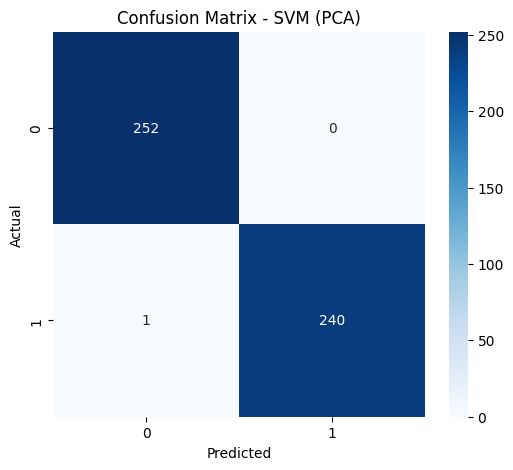

In [ ]:
accuracy_records = []

# Check exactly which features the model was trained on (using the updated features_used)
# features_used should contain the columns of X_train after all dropping and subsetting
print(f"Features used for training ({len(features_used)}): {features_used}")


# Make sure test data matches those features:
print("Test data columns before alignment:", X_test.columns.tolist())
print(f"Number of features in test data before alignment: {len(X_test.columns)}")


# Subset and reorder your test data columns using that list:
X_test_aligned = X_test[features_used]

# Check for Missing Columns in Test after initial subsetting
missing_cols = set(features_used) - set(X_test_aligned.columns)
print("Missing columns in test set after initial alignment:", missing_cols)
if missing_cols:
    print("Error: Missing columns in test set after initial alignment.")


# Scale aligned test data (same scaler fitted on training data):
# Assuming the scaler was fitted on X_train which had columns defined by features_used.
X_test_scaled_aligned = scaler.transform(X_test_aligned)

# Debugging prints after scaling (optional, but can confirm dimension)
# print(f"Shape of X_test_scaled_aligned: {X_test_scaled_aligned.shape}")


# Predict Using Scaled and Aligned Test Data

# Classical models without PCA
for name, clf in models.items():
    print(f"\n{name} (No PCA):")
    # Re-train the model within this cell to ensure consistency
    clf.fit(X_train_scaled, y_train_noisy)
    y_pred = clf.predict(X_test_scaled_aligned)
    acc = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {acc:.4f}")
    accuracy_records.append([name, acc])

# Classical models with PCA
for name, clf in models.items():
    print(f"\n{name} (PCA):")
    # Re-train the model within this cell to ensure consistency
    clf.fit(X_train_pca, y_train_noisy)
    y_pred = clf.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {acc:.4f}")
    accuracy_records.append([name + ' (PCA)', acc])

# ANN accuracies
# The accuracy variable from the previous cell is the ANN (No PCA) accuracy.
loss_no_pca, accuracy_no_pca = ann.evaluate(X_test_scaled_aligned, y_test_cat, verbose=0) # Evaluate ANN (No PCA) with correct scaled data
accuracy_records.append(['ANN (No PCA)', accuracy_no_pca])

ann_pca_acc = ann_pca.evaluate(X_test_pca, y_test_cat, verbose=0)[1]
accuracy_records.append(['ANN (PCA)', ann_pca_acc])


accuracy_df = pd.DataFrame(accuracy_records, columns=['Algorithm', 'Accuracy'])
print(accuracy_df)

best_row = accuracy_df.iloc[accuracy_df['Accuracy'].idxmax()]
best_name = best_row['Algorithm']

# Determine the best model and predict on the test set
if best_name == 'ANN (No PCA)':
    y_pred_best = ann.predict(X_test_scaled_aligned).argmax(axis=1)
elif best_name == 'ANN (PCA)':
    y_pred_best = ann_pca.predict(X_test_pca).argmax(axis=1)
elif 'PCA' in best_name:
    base_name = best_name.replace(' (PCA)', '')
    # Re-train the best PCA model before predicting
    best_model_pca = models[base_name]
    best_model_pca.fit(X_train_pca, y_train_noisy)
    y_pred_best = best_model_pca.predict(X_test_pca)
else:
    # Re-train the best non-PCA model before predicting
    best_model_no_pca = models[best_name]
    best_model_no_pca.fit(X_train_scaled, y_train_noisy)
    y_pred_best = best_model_no_pca.predict(X_test_scaled_aligned)


cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from IPython.display import display
display(accuracy_df)

,Algorithm,Accuracy
0,Random Forest,0.971602
1,SVM,0.975659
2,XGBoost,0.953347
3,Gradient Boosting,0.979716
4,Random Forest (PCA),0.993915
5,SVM (PCA),0.997972
6,XGBoost (PCA),0.971602
7,Gradient Boosting (PCA),0.991886
8,ANN (No PCA),0.965517
9,ANN (PCA),0.993915
